# Part 1 - Creating a MotifCompendium object
The MotifCompendium package provides a framework for clustering, annotating, and analyzing motifs efficiently at large scales. This tutorial will walk you through the steps of how to do just that! Note that the following code should be treated as a minimal example of how to use MotifCompendium. Please refer to subsequent tutorials in order to see how to make the most out of MotifCompendium. Also, **please read the written sections of this tutorial in addition to following along with the code**.

Let's begin by importing the MotifCompendium package!

In [1]:
import MotifCompendium

The first thing you should do whenever you import MotifCompendium is set the MotifCompendium compute options. These options will dictate how certain functions from the package are run. **Note that these options never modify function correctness but can modify performance, and can be used to speed up your code.** 

These are the following options that are available:

- `max_cpus` (`int`): The number of processes to use. This can be used to parallelize computing motif similarity, loading data, and generating plots. You'll want to set this as high as possible.
- `use_gpu` (`bool`): Whether or not to GPU-accelerate calculations. This is currently only used to accelerate similarity calculations. You'll want to set this to True if possible.
- `max_chunk` (`int`): The maximum number of motifs to compute similarity for at a time. Similarity calculations will be done in `max_chunk` x `max_chunk` chunks at a time. This is primarily used when trying to fit GPU calculations into on-device memory. For a GPU with ~12GB of memory, for instance, use a `max_chunk` of 1152. If never set or set to -1, similarity calculations will not be chunked. If `use_gpu` is `False` and `max_cpus > 1`, then similarity calculation chunks will be parallelized across multiple cores.
- `fast_plotting` (`bool`): Whether or not to plot motif logos using custom plotting code instead of with `logomaker`. Plotting is ~30% faster with `fast_plotting` set to `True`, but the logos may not look as pretty.
- `progress_bar` (`bool`): Whether or not to display a progress bar for certain calculations. This is currently only used to show the progress of similarity calculations.

Note that these options can be set and changed at any time, but it is best practice to set them at the beginning of any code using MotifCompendium.

For this tutorial, we will be assuming that we don't have a GPU but have access to 4 CPUs.

In [2]:
MotifCompendium.set_compute_options(max_cpus=4, progress_bar=True)

If we did have a GPU, we could have considered running `MotifCompendium.set_compute_options(max_chunk=4, use_gpu=True, max_chunk=1152, progress_bar=True)`.

A common use case for MotifCompendium is analyzing *de novo* motifs learned by deep learning models. In this tutorial, we will use motifs discovered by Modisco from ChromBPNet attributions.

If we have multiple Modisco runs that we want to analyze all the motifs from, all we need to do is create a dictionary from model name to Modisco file path. Then, we can build a MotifCompendium object by using the `build_from_modisco()` function.

In [3]:
modisco_dict = {
    "cardiomyocyte": "/oak/stanford/groups/akundaje/salil512/resources/MotifCompendium_Tutorial_Resources/cardiomyocyte_modisco_output.h5",
    "endothelial": "/oak/stanford/groups/akundaje/salil512/resources/MotifCompendium_Tutorial_Resources/endothelial_modisco_output.h5"
}
mc = MotifCompendium.build_from_modisco(modisco_dict)
mc

,name,num_seqlets,model,posneg
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos
...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos
84,endothelial-pos.pattern_6,2977,endothelial,pos
85,endothelial-pos.pattern_7,2358,endothelial,pos
86,endothelial-pos.pattern_8,2115,endothelial,pos


And just like that we have a MotifCompendium object we can begin to work with!

 But what happened in the build_from_modisco() function and what is a MotifCompendium object?

In the back end, all 88 motifs were read from both Modisco outputs. Then, the pairwise similarity of all 88 motifs were computed. The similarity between any two motifs is a score between 0 and 1 where 0 represents that the motifs have no overlap and 1 represents that the two motifs are identical. The similarity score takes into accounts all possible orientations of the motifs being compared.

The MotifCompendium object is the backbone of this package. It is an object that you can use to better analyze, organize, and store your clusters. The MotifCompendium object has 5 attributes you can interact with:

- `motifs`: The motifs themselves.
- `similarity`: A square matrix containing pairwise similarity scores between the motifs.
- `alignment_rc`: A square matrix containing information about if motifs need to be reverse complemented to best align with each other.
- `alignment_h`: A square matrix containing information about how much motifs need to be shifted horizontally (after being reverse complemented) in order to best align with each other.
- `metadata`: A DataFrame that stores information about each motif.

You can but should rarely if ever need to interact with these object attributes directly.

Let's visualize the similarity matrix by calling the `heatmap()` method.

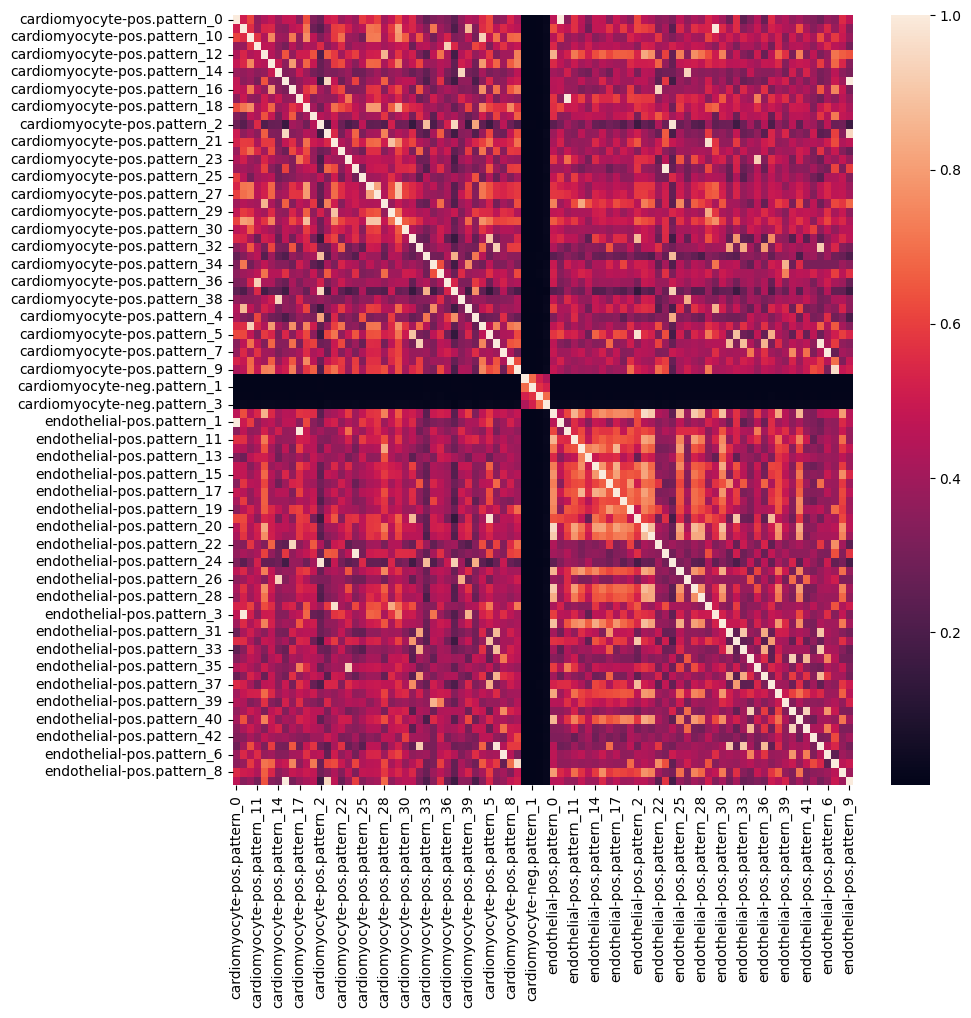

In [4]:
mc.heatmap(show=True, label=True)

The similarity matrix has some interesting structure! Notice that there are 1s all along the diagonal. This is because every motif achieves the maximum possibility of 1 with itself. Also, notice how there are 4 negative cardiomyocyte motifs that have 0 similarity with any of the other positive motifs.

The rest of this tutorial will focus on how to use the MotifCompendium object to cluster and annotate motifs.

# Part 2 - Clustering Motifs

Before clustering a MotifCompendium object, you must select a similarity threshold to cluster with. The similarity threshold is a number between 0 and 1 above which all motifs are considered similar enough to cluster together.

We will begin by importing the analysis submodule. This submodule contains many useful functions for performing analyses with MotifCompendium objects.

In [5]:
import MotifCompendium.utils.analysis as utils_analysis

Now, we will use the `plot_similarity_distribution()` function in order to see examples of what different similarity thresholds look like. The function produces an HTML file in the specified location that has examples of pairs of motifs at a set of specified similarity thresholds. We will produce the plot and then identify a similarity threshold that looks good to us.

Note: Normally, you do not to modify the tolerance parameter of this function. However, because the tutorial example only has 88 motifs, we need to be a little looser when identifying motif pairs of a particular similarity, so we have increased the `tolerance` parameter from its default value of 0.001 to 0.005.

In [6]:
utils_analysis.plot_similarity_distribution(mc, "tutorial_outputs/similarity_distribution.html", tolerance=0.005)

When we look at the [similarity distribution](tutorial_outputs/similarity_distribution.html), we can see examples of motif pairs at different similarity thresholds.

In this case, suppose we feel that all motif pairs with a similarity threshold of 0.96 or above looked similar enough by eye and all motif pairs with a similarity threshold of 0.95 and below looked distinct in some way. Then, we would proceed by using a similarity threshold of 0.96.

**This manual threshold identification process may feel imprecise but there is unfortunately no univeral similarity threshold that will be appropriate for all data/use cases. As such, it is strongly recommended that you use always use this pattern to identify a similarity threshold before clustering.**

Now that we've picked a similarity threshold, we can move onto clustering!

We can call the MotifCompendium object's `cluster()` function with our similarity threshold of 0.96.

In [7]:
mc.cluster(similarity_threshold=0.96)
mc

,name,num_seqlets,model,posneg,cluster
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,8
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,11
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,12
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,13
...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,9
84,endothelial-pos.pattern_6,2977,endothelial,pos,10
85,endothelial-pos.pattern_7,2358,endothelial,pos,4
86,endothelial-pos.pattern_8,2115,endothelial,pos,76


Notice how the MotifCompendium object was automatically updated with a new `cluster` column. That column indicates which motif cluster that motif should belong to. There are many details about and options for performing motif clustering in the MotifCompendium package. Please refer to [tutorial 3](3_motif_clustering.ipynb) for details on how most effectively perform motif clustering in MotifCompendium.

As a preliminary visualization, let's visualize the similarity matrix when we sort our motifs by which cluster they belong to.

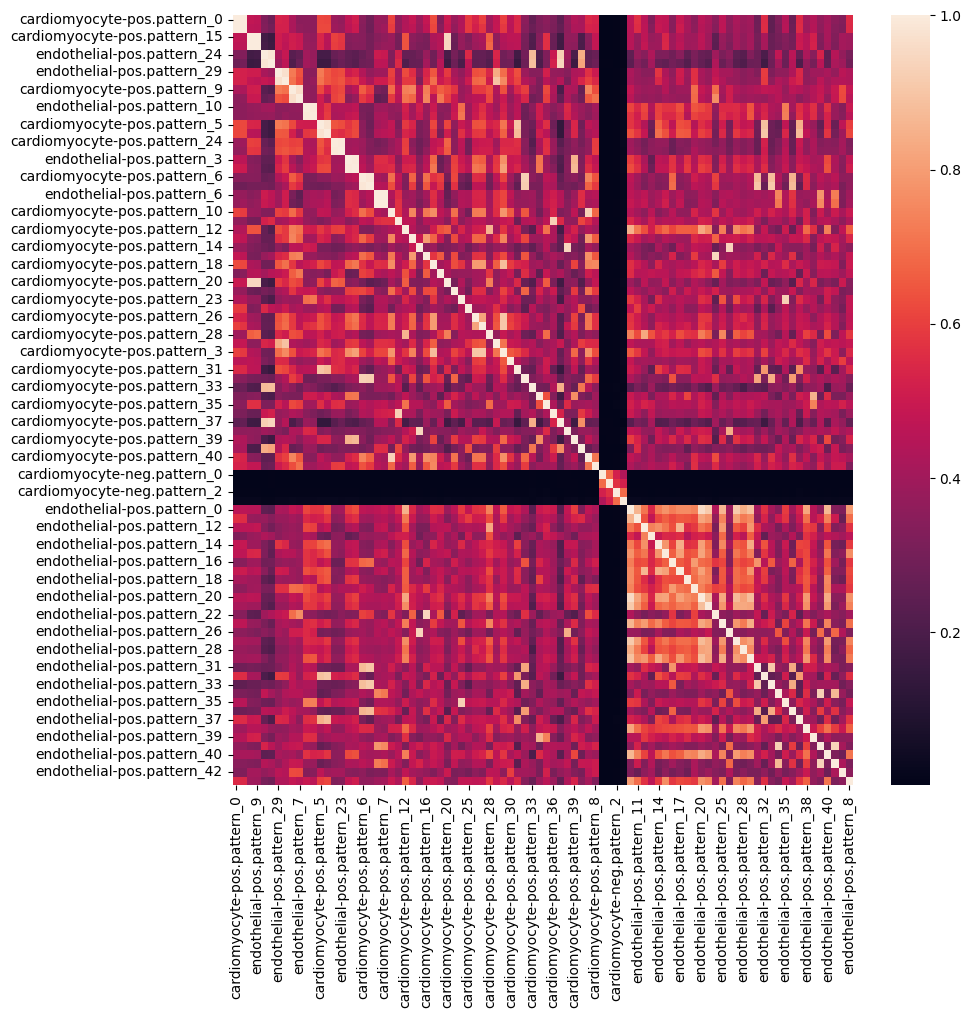

In [8]:
mc.sort(by="cluster").heatmap(show=True, label=True)

The block diagonal stricture shows that we have clustered motifs that are similar together!

Now, let's look at two other standard visualizations we can produce to help us better understand the results of this clustering.

First, we will call the MotifCompendium object's `motif_collection_html()` method to look the makeup of each motif cluster. The `"cluster"` argument tells the function that we are looking to view the motifs as grouped by the `"cluster"` column of the object's metadata.

In [9]:
mc.motif_collection_html("tutorial_outputs/motif_collection.html", "cluster")

When we look at the [motif collection](tutorial_outputs/motif_collection.html), we can see each cluster and its constituent motifs. The green box at the top of each cluster shows the average motif for that cluster (the average of all the constituents). Underneath that, all of the motifs in that cluster are shown. The name given to each motif in the column is based on the information in the `name` column in the MotifCompendium's metadata. Notice how all of the motifs in the clusters are aligned with each other. We are able to display the motifs this way because we have computed and stored the information about optimal motif alignment when we built the MotifCompendium initially!

Next, we will produce a table that has information about each cluster. To do this, we will produce an "averaged" MotifCompendium object where each motif in the new MotifCompendium represents one cluster in the current MotifCompendium.

In [10]:
mc_avg = mc.cluster_averages("cluster")
mc_avg

,name,source_cluster,num_constituents
0,cluster#0,0,2
1,cluster#1,1,2
2,cluster#2,2,2
3,cluster#3,3,2
4,cluster#4,4,2
...,...,...,...
72,cluster#72,72,1
73,cluster#73,73,1
74,cluster#74,74,1
75,cluster#75,75,1


The `mc_avg` MotifCompendium object has 77 motifs in it because we had 77 clusters in our initial clustering. Notice how some information is automatically populated into the table such as the number of constituents in each cluster. Let's add in another informative column like a string representation of each motif.

In [11]:
mc_avg.add_motif_strings()
mc_avg

,name,source_cluster,num_constituents,motif_string
0,cluster#0,0,2,GCC--CT-G-GG<br/>CC-C-AG--GGC
1,cluster#1,1,2,GCGC-TGCGC<br/>GCGCA-GCGC
2,cluster#2,2,2,CTATTTTTAG<br/>CTAAAAATAG
3,cluster#3,3,2,AA-ATGGCGGC<br/>GCCGCCAT-TT
4,cluster#4,4,2,TGACGT-A<br/>T-ACGTCA
...,...,...,...,...
72,cluster#72,72,1,AACAAT-G<br/>C-ATTGTT
73,cluster#73,73,1,GGAA-CTTCCTG<br/>CAGGAAG-TTCC
74,cluster#74,74,1,CAA---ACAATG<br/>CATTGT---TTG
75,cluster#75,75,1,GTT-CCAT-G--ACG<br/>CGT--C-ATGG-AAC


There's now a new column called motif_string that has ATCG representations of each motif.

Now, we will produce a spreadsheet-like table where each row is one of the motifs in `mc_avg`, which represents a cluster in the original MotifCompendium object.

In [12]:
mc_avg.summary_table_html("tutorial_outputs/cluster_summary_table.html")

When we look at the [cluster summary table](tutorial_outputs/cluster_summary_table.html), we see a table where each row is a motif cluster. Each column represents a column in `mc_avg`. The columns can be sorted and searched for ease of use!

**Summary tables are the best way to interactively view and analyze a MotifCompendium.** Please refer to [tutorial 4](4_visualization.ipynb) for details on how most effectively use motif collections and summary tables to visualize and display the contents of MotifCompendium objects.

# Part 3 - Annotation

Once we have clusters of motifs, we will want to annotate them in order to know which TFs may be binding to them. Instead of doing this process manually, we can try to leverage databases of PFMs or even existing and annotated MotifCompendium objects in order to automatically label our motifs.

We will annotate each cluster and then import those labels back into the original MotifCompendium object.

Let us start by annotating our motifs based on the HOCOMOCO13 database. We will do this by calling the `label_from_pfms` function and providing it with the MotifCompendium object we want to label, the path to a PFM file, and a column prefix (in this case, `"h13"`).

In [13]:
utils_analysis.label_from_pfms(
    mc_avg,
    "/oak/stanford/groups/akundaje/salil512/resources/MotifCompendium_Tutorial_Resources/H13CORE_pfms.txt",
    "h13")
mc_avg

,name,source_cluster,num_constituents,motif_string,h13_score0,h13_name0
0,cluster#0,0,2,GCC--CT-G-GG<br/>CC-C-AG--GGC,0.975609,CTCF.H13CORE.0.P.B
1,cluster#1,1,2,GCGC-TGCGC<br/>GCGCA-GCGC,0.940604,NRF1.H13CORE.0.PS.A
2,cluster#2,2,2,CTATTTTTAG<br/>CTAAAAATAG,0.937829,MEF2D.H13CORE.0.PS.A
3,cluster#3,3,2,AA-ATGGCGGC<br/>GCCGCCAT-TT,0.926223,TYY1.H13CORE.0.PSM.A
4,cluster#4,4,2,TGACGT-A<br/>T-ACGTCA,0.950344,CREM.H13CORE.0.PSM.A
...,...,...,...,...,...,...
72,cluster#72,72,1,AACAAT-G<br/>C-ATTGTT,0.989976,SOX8.H13CORE.1.PS.A
73,cluster#73,73,1,GGAA-CTTCCTG<br/>CAGGAAG-TTCC,0.865983,ETV4.H13CORE.0.P.B
74,cluster#74,74,1,CAA---ACAATG<br/>CATTGT---TTG,0.929178,SOX8.H13CORE.1.PS.A
75,cluster#75,75,1,GTT-CCAT-G--ACG<br/>CGT--C-ATGG-AAC,0.853898,RFX2.H13CORE.1.PSM.A


Notice how `mc_avg` now has two extra columns: `h13_score0` and `h13_name0`. `h13_name0` contains the most similar match in the HOCOMOCO13 database and `h13_score0` contains the similarity score of said match.

**Notice that the best match is provided even if it is a bad match. It will be on you to decide if that is an appropriate match or not.**

We can even use a previously labeled MotifCompendium object in order to label our MotifCompendium! Let's begin by loading in an already labeled MotifCompendium object.

In [14]:
previously_labeled_mc = MotifCompendium.load("/oak/stanford/groups/akundaje/salil512/resources/MotifCompendium_Tutorial_Resources/selin_compendium.mc")
previously_labeled_mc

,name,num_seqlets,model,posneg,organ,merged_pattern,annotation
0,Muscle_c5-pos.pattern_0,19177,Muscle_c5,pos,Muscle,pos.Average_305__merged_pattern_0,CTCF#1
1,Muscle_c5-pos.pattern_1,12674,Muscle_c5,pos,Muscle,pos.Average_294__merged_pattern_0,BHLH:TFAP/MYOD#1
2,Muscle_c5-pos.pattern_10,1907,Muscle_c5,pos,Muscle,pos.Average_282__merged_pattern_0,RFX#1
3,Muscle_c5-pos.pattern_11,1693,Muscle_c5,pos,Muscle,pos.Average_85__merged_pattern_0,BZIP:ATF/CREB#1
4,Muscle_c5-pos.pattern_12,1626,Muscle_c5,pos,Muscle,pos.Average_161__merged_pattern_0,ZNF143#1
...,...,...,...,...,...,...,...
6162,Stomach_c11-pos.pattern_5,3273,Stomach_c11,pos,Stomach,pos.Average_280__merged_pattern_0,BZIP:ATF/CREB#1
6163,Stomach_c11-pos.pattern_6,2650,Stomach_c11,pos,Stomach,pos.Average_159__merged_pattern_0,NRF1
6164,Stomach_c11-pos.pattern_7,2506,Stomach_c11,pos,Stomach,pos.Average_303__merged_pattern_4,HD:MEIS/TGIF
6165,Stomach_c11-pos.pattern_8,1686,Stomach_c11,pos,Stomach,pos.Average_255__merged_pattern_0,SRF#1


Notice how this MotifCompendium object already has an annotation column. We will use these annotations in order to label our motif clusters. We will do this by calling the `assign_label_from_other` method of our MotifCompendium object and providing it with the already annotated MotifCompendium object, the column in that object containing annotations, and the column prefix to save new information to in our MotifCompendium.

In [15]:
mc_avg.assign_label_from_other(previously_labeled_mc, "annotation", "labeled_mc")
mc_avg

,name,source_cluster,num_constituents,motif_string,h13_score0,h13_name0,labeled_mc_score0,labeled_mc_name0
0,cluster#0,0,2,GCC--CT-G-GG<br/>CC-C-AG--GGC,0.975609,CTCF.H13CORE.0.P.B,0.999792,CTCF#1
1,cluster#1,1,2,GCGC-TGCGC<br/>GCGCA-GCGC,0.940604,NRF1.H13CORE.0.PS.A,0.999636,NRF1
2,cluster#2,2,2,CTATTTTTAG<br/>CTAAAAATAG,0.937829,MEF2D.H13CORE.0.PS.A,0.995122,MEF2
3,cluster#3,3,2,AA-ATGGCGGC<br/>GCCGCCAT-TT,0.926223,TYY1.H13CORE.0.PSM.A,0.995809,YY1/2
4,cluster#4,4,2,TGACGT-A<br/>T-ACGTCA,0.950344,CREM.H13CORE.0.PSM.A,0.998530,BZIP:ATF/CREB#1
...,...,...,...,...,...,...,...,...
72,cluster#72,72,1,AACAAT-G<br/>C-ATTGTT,0.989976,SOX8.H13CORE.1.PS.A,0.998744,SOX#1
73,cluster#73,73,1,GGAA-CTTCCTG<br/>CAGGAAG-TTCC,0.865983,ETV4.H13CORE.0.P.B,0.879517,ETS:ELF/ETV#1
74,cluster#74,74,1,CAA---ACAATG<br/>CATTGT---TTG,0.929178,SOX8.H13CORE.1.PS.A,0.935559,SOX#1
75,cluster#75,75,1,GTT-CCAT-G--ACG<br/>CGT--C-ATGG-AAC,0.853898,RFX2.H13CORE.1.PSM.A,0.990340,RFX#1


Once again, `mc_avg` has two additional columns: `labeled_mc_score0` and `labeled_mc_name0`. For each motif in `mc_avg`, `labeled_mc_score0` contains the similarity score of the most similar motif in the MotifCompendium object we compared against and `labeled_mc_name0` contains the matching motif's value in the `annotation` column.

Now that we have two sets of labels (one from HOCOMOCO13 and the other from a previously labeled MotifCompendium), let's suppose we want to come up with a single label considering both. The following code pattern will help us pick a single label and then apply that label back to our original motifs.

In [16]:
cluster_labels_dict = dict()
for index, row in mc_avg.metadata.iterrows():
    if row["labeled_mc_score0"] > 0.9:
        cluster_labels_dict[index] = f"{row['labeled_mc_name0']}_{index}".replace("/", "-")
    elif row["h13_score0"] > 0.9:
        cluster_labels_dict[index] = f"{row['h13_name0']}_{index}"
    else:
        cluster_labels_dict[index] = f"Unknown_{index}"
mc["annotation"] = mc["cluster"].map(cluster_labels_dict)
mc

,name,num_seqlets,model,posneg,cluster,annotation
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0,CTCF#1_0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,8,NFI#1_8
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,11,HD:MEIS-TGIF_11
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,12,GATA#1_12
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,13,ETS:ELF-ETV#1_13
...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,9,BZIP:FOSL-JUND#1_9
84,endothelial-pos.pattern_6,2977,endothelial,pos,10,NFY_10
85,endothelial-pos.pattern_7,2358,endothelial,pos,4,BZIP:ATF-CREB#1_4
86,endothelial-pos.pattern_8,2115,endothelial,pos,76,ETS:ELF-SPIB#1_76


Now we've assigned TF annotations to each of our motifs!

There are many more details about options and best practices for labeling motifs. Please refer to [tutorial 5](5_motif_annotation.ipynb) for details.

# Part 4 - Saving/Loading

To save your progress, you will want to save your MotifCompendium object. You can call the object's `save` method.

In [17]:
mc.save("tutorial_outputs/tutorial_motif_compendium.mc")

If you have a previously saved MotifCompendium object, you will want to load it from file. It is exactly the same after loading.

In [18]:
mc_test = MotifCompendium.load("tutorial_outputs/tutorial_motif_compendium.mc")
print(f"MotifCompendiums match: {mc_test == mc}")
mc_test

MotifCompendiums match: True


,name,num_seqlets,model,posneg,cluster,annotation
0,cardiomyocyte-pos.pattern_0,24730,cardiomyocyte,pos,0,CTCF#1_0
1,cardiomyocyte-pos.pattern_1,23251,cardiomyocyte,pos,8,NFI#1_8
2,cardiomyocyte-pos.pattern_10,4122,cardiomyocyte,pos,11,HD:MEIS-TGIF_11
3,cardiomyocyte-pos.pattern_11,4008,cardiomyocyte,pos,12,GATA#1_12
4,cardiomyocyte-pos.pattern_12,3352,cardiomyocyte,pos,13,ETS:ELF-ETV#1_13
...,...,...,...,...,...,...
83,endothelial-pos.pattern_5,3338,endothelial,pos,9,BZIP:FOSL-JUND#1_9
84,endothelial-pos.pattern_6,2977,endothelial,pos,10,NFY_10
85,endothelial-pos.pattern_7,2358,endothelial,pos,4,BZIP:ATF-CREB#1_4
86,endothelial-pos.pattern_8,2115,endothelial,pos,76,ETS:ELF-SPIB#1_76


If you don't want to fully load it into memory but just want to inspect its contents, you can do so with the `inspect` function. This function prints out the contents of a MotifCompendium object without actually fully loading it from file. It also returns the object's metadata as a Pandas DataFrame. This function may be useful when working with large MotifCompendium.

In [19]:
file_metadata = MotifCompendium.inspect("tutorial_outputs/tutorial_motif_compendium.mc")

MotifCompendium with 88 motifs.
--- Motifs = (88, 30, 8) ---

--- Metadata ---
                            name  num_seqlets          model posneg  cluster  \
0    cardiomyocyte-pos.pattern_0        24730  cardiomyocyte    pos        0   
1    cardiomyocyte-pos.pattern_1        23251  cardiomyocyte    pos        8   
2   cardiomyocyte-pos.pattern_10         4122  cardiomyocyte    pos       11   
3   cardiomyocyte-pos.pattern_11         4008  cardiomyocyte    pos       12   
4   cardiomyocyte-pos.pattern_12         3352  cardiomyocyte    pos       13   
..                           ...          ...            ...    ...      ...   
83     endothelial-pos.pattern_5         3338    endothelial    pos        9   
84     endothelial-pos.pattern_6         2977    endothelial    pos       10   
85     endothelial-pos.pattern_7         2358    endothelial    pos        4   
86     endothelial-pos.pattern_8         2115    endothelial    pos       76   
87     endothelial-pos.pattern_9         

# Part 5 - Conclusion

This tutorial introduced you to the basic syntax and interface of the MotifCompendium package. You've now seen how MotifCompendium objects are built, clustered, annotated, saved, and loaded. **Please review the other tutorials for more details about the MotifCompendium object, more details about how to best perform all of these steps, and ideas for more downstream analyses that can be performed with MotifCompendium**. Consider reviewing the [tutorial 2](2_motifcompendium_object.ipynb) next.

Thank you so much for trying out MotifCompendium!